In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
from scipy.stats import chi2_contingency
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

In [2]:
##Load train and test set
train_df = pd.read_csv('train_data.txt')
test_df = pd.read_csv('test_data.txt')

train_df.head(10)

,ID,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,1,33,1,3,2,8,0,5,1,3,...,0,0,0,1,0,0,0,0,0,0
1,2,37,1,2,2,8,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0
2,3,37,1,2,2,8,0,4,2,4,...,0,0,0,1,0,0,0,0,0,0
3,4,9,1,3,3,3,2,3,2,4,...,0,0,0,1,0,0,0,0,0,0
4,5,40,1,4,2,10,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0
5,6,23,1,2,1,5,0,5,0,5,...,0,0,0,0,0,0,0,0,0,0
6,7,39,2,3,2,9,2,2,0,5,...,0,0,0,0,0,0,0,0,0,0
7,8,33,1,2,3,8,0,7,0,2,...,0,0,0,0,0,0,0,0,0,0
8,9,33,1,2,4,8,0,1,3,6,...,0,0,0,0,0,0,0,0,0,0
9,10,11,2,3,3,3,3,5,0,2,...,0,0,0,1,0,0,0,0,0,0


In [3]:
print("\n=== Basic Dataset Information ===")
print(f"Dataset Shape: {train_df.shape}")
print("\nMissing Values (if any):")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])


=== Basic Dataset Information ===
Dataset Shape: (5822, 87)

Missing Values (if any):
Series([], dtype: int64)


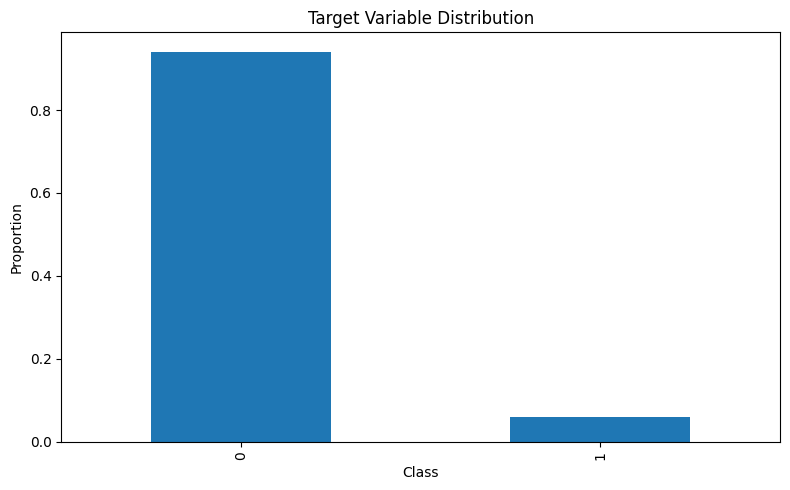


=== Target Distribution ===
86
0    0.940227
1    0.059773
Name: proportion, dtype: float64

Class Imbalance Ratio: 15.73%


In [4]:
##Check target variable (86) distribution
plt.figure(figsize=(8, 5))
target_dist = train_df['86'].value_counts(normalize=True)
target_dist.plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()
        
print("\n=== Target Distribution ===")
print(train_df['86'].value_counts(normalize=True))
        
##Calculate class imbalance ratio
imbalance_ratio = target_dist.max() / target_dist.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}%")

In [5]:
##Check if test data contains any exclusive value from train data
new_values_dict = {}
for col in test_df.columns:
    if col in train_df.columns:
        train_values = set(train_df[col].astype(int).unique())
        test_values = set(test_df[col].astype(int).unique())
        new_values = test_values - train_values  # Set difference
        if new_values:
            new_values_dict[col] = list(new_values)

if new_values_dict:
    print("New values found in test_df:")
    for col, values in new_values_dict.items():
        print(f"  Column '{col}': {values}")
else:
    print("No new values found in test_df compared to train_df.")

New values found in test_df:
  Column '3': [np.int64(6)]
  Column '29': [np.int64(8)]
  Column '33': [np.int64(9)]
  Column '41': [np.int64(6)]
  Column '46': [np.int64(1)]
  Column '47': [np.int64(9)]
  Column '50': [np.int64(7)]
  Column '52': [np.int64(7)]
  Column '53': [np.int64(1)]
  Column '60': [np.int64(2)]
  Column '68': [np.int64(12), np.int64(5)]
  Column '69': [np.int64(5)]
  Column '70': [np.int64(3)]
  Column '71': [np.int64(4)]
  Column '73': [np.int64(5), np.int64(6)]
  Column '74': [np.int64(4)]
  Column '75': [np.int64(3)]
  Column '76': [np.int64(5)]
  Column '80': [np.int64(6)]
  Column '83': [np.int64(4)]


With quite a few columns in <code>test_df</code> contain <b>unseen data</b> in <code>train_df</code>, consider an encoding method that can work well in this situation.
All unseen value columns are <b>numeric</b>

In [6]:
##Check for correlation between 2 categorical columns: 1 & 5 (based on Attribute Description file)
##Create the contingency table
contingency = pd.crosstab(train_df['1'], train_df['5'])
    
##Calculate Chi-square statistic and p-value
chi2, p_value, dof, expected = chi2_contingency(contingency)
    
##Calculate Cramer's V
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramer_v = np.sqrt(chi2 / (n * min_dim))
    
##Prepare additional statistics
stats = {
    #'contingency_table': contingency,
    'chi_square': chi2,
    'p_value': p_value,
    'degrees_of_freedom': dof,
    'sample_size': n
}
print(f"Cramer's V = {cramer_v:.4f}")
print(f"\nChi-square statistic: {stats['chi_square']:.4f}")
print(f"P-value: {stats['p_value']:.4f}")
print(f"Degrees of freedom: {stats['degrees_of_freedom']}")
print(f"Sample size: {stats['sample_size']}")

Cramer's V = 1.0000

Chi-square statistic: 52398.0000
P-value: 0.0000
Degrees of freedom: 351
Sample size: 5822


Since column 1 and 5 are <b>highly correlated</b> with <code>p-value = 0</code> and <code>Cramer's V = 1</code>, I will process to drop column with lower IV, eventually <b>keep column 1</b>


=== Highly Correlated Features (>0.8) ===
10 -- 12: -0.884
30 -- 31: -1.000
35 -- 36: -0.999
44 -- 65: 0.981
45 -- 66: 0.895
46 -- 67: 0.988
47 -- 68: 0.916
48 -- 69: 0.903
49 -- 70: 0.905
50 -- 71: 0.949
51 -- 72: 0.966
52 -- 73: 0.930
53 -- 74: 0.910
54 -- 75: 0.970
55 -- 76: 0.850
56 -- 77: 0.898
57 -- 78: 0.980
58 -- 79: 0.948
59 -- 80: 0.866
60 -- 81: 0.870
61 -- 82: 0.904
62 -- 83: 0.936
63 -- 84: 0.875
64 -- 85: 0.966


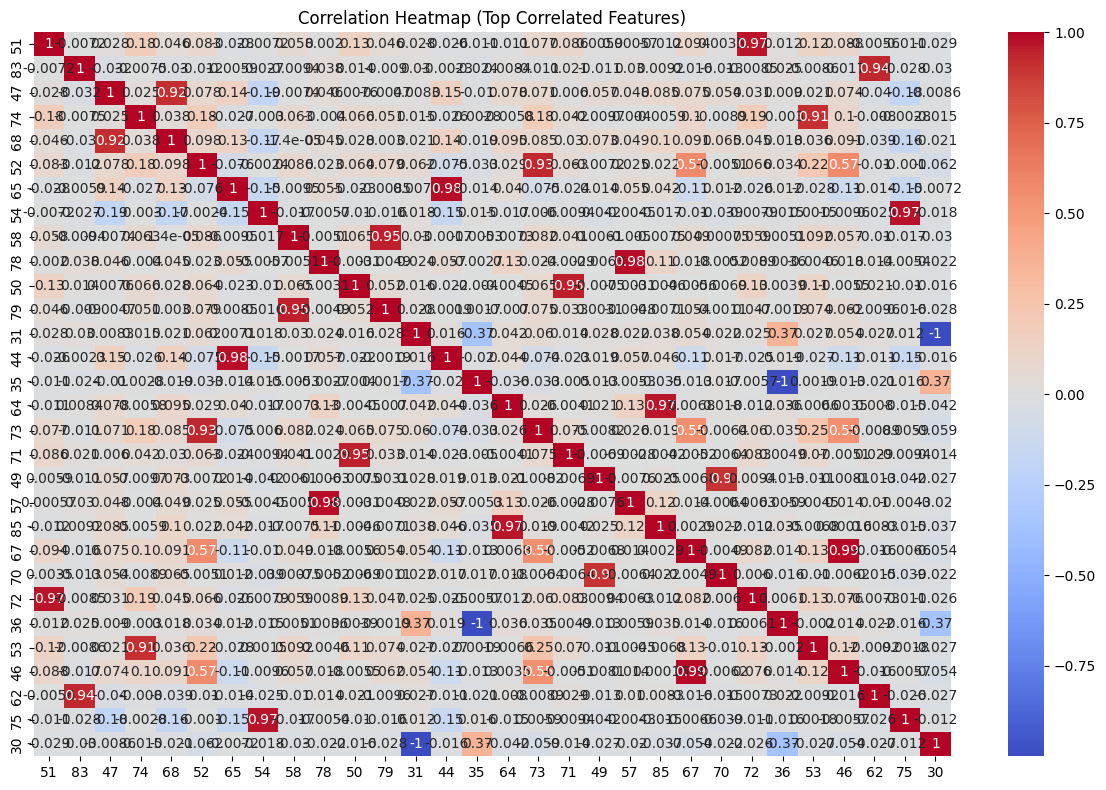

In [7]:
##Correlation analysis
corr_matrix = train_df.drop(columns=['ID', '1', '5', '86']).corr()
    
##Find highly correlated features
high_corr_features = np.where(np.abs(corr_matrix) > 0.8)
high_corr_features = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) 
                         for x, y in zip(*high_corr_features) if x != y and x < y]
    
print("\n=== Highly Correlated Features (>0.8) ===")
for feat1, feat2, corr in high_corr_features:
    print(f"{feat1} -- {feat2}: {corr:.3f}")
    
##Plot correlation heatmap for features with highest correlation
plt.figure(figsize=(12, 8))
most_corr_features = sorted(high_corr_features, key=lambda x: abs(x[2]), reverse=True)[:15]
if most_corr_features:
    most_corr_feat_names = list(set([x[0] for x in most_corr_features] + [x[1] for x in most_corr_features]))
    sns.heatmap(corr_matrix.loc[most_corr_feat_names, most_corr_feat_names],
                   annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Top Correlated Features)')
    plt.tight_layout()
    plt.show()

In [8]:
##Calculate WOE and IV for both categorical and numeric variables
def calculate_woe_iv(df, column, target, is_categorical=False, bins=10):

    temp_df = df[[column, target]].copy()
    
    ##Create binned group for numeric columns
    if not is_categorical:
        temp_df['bins'] = pd.qcut(temp_df[column].astype(int), q=bins, duplicates='drop')
        grouping_column = 'bins'
    else:
        grouping_column = column
    
    ##Calculate WOE
    total_pos = temp_df[target].sum()
    total_neg = len(temp_df) - total_pos
    
    grouped = temp_df.groupby(grouping_column, observed=True).agg({target: ['count', 'sum']})
    
    grouped.columns = ['total', 'pos']
    grouped['neg'] = grouped['total'] - grouped['pos']
    
    ##Add 0.0001 constant to prevent division by zero
    grouped['pos_rate'] = (grouped['pos'] + 0.0001) / total_pos
    grouped['neg_rate'] = (grouped['neg'] + 0.0001) / total_neg
    grouped['woe'] = np.log(grouped['pos_rate'] / grouped['neg_rate'])
    grouped['iv'] = (grouped['pos_rate'] - grouped['neg_rate']) * grouped['woe']
    
    # Calculate event rate for interpretation
    grouped['event_rate'] = grouped['pos'] / grouped['total']
    
    return grouped, grouped['iv'].sum()

##Encode the dataset using WOE mapping
def apply_woe_encoding(df, target_col):
    ##Identify numeric and categorical columns
    categorical_cols = ['1']
    numeric_cols = [col for col in df.columns if col not in categorical_cols and col != target_col]
    
    ##Create WOE encoded dataframe
    woe_mappings = {}
    information_values = {}
    woe_encoded_df = pd.DataFrame(index=df.index)
    woe_encoded_df[target_col] = df[target_col]
    
    # Process categorical variables
    for col in categorical_cols:
        woe_info, iv = calculate_woe_iv(df, col, target_col, is_categorical=True)
        woe_mappings[col] = woe_info['woe']
        information_values[col] = iv
        
        # Map WOE values to data
        woe_encoded_df[f'{col}_woe'] = df[col].map(woe_info['woe'])
    
    # Process numeric variables
    for col in numeric_cols:
        woe_info, iv = calculate_woe_iv(df, col, target_col, is_categorical=False, bins=10)
        woe_mappings[col] = woe_info
        information_values[col] = iv
        
        # Create bins and map WOE values
        bins = pd.qcut(df[col].astype(int), q=10, duplicates='drop')
        woe_encoded_df[f'{col}_woe'] = bins.map(woe_info['woe'])
    
    return woe_encoded_df, woe_mappings, information_values

In [9]:
##Drop columns based on previous highly correlated list
features_to_remove = ['5']
for feat1, feat2, corr in high_corr_features:
    iv1 = calculate_woe_iv(train_df, feat1, '86', is_categorical=False, bins=10)[1]
    iv2 = calculate_woe_iv(train_df, feat2, '86', is_categorical=False, bins=10)[1]

    ##Remove feature with lower IV
    if iv1 < iv2:
        features_to_remove.append(feat1)
    else:
        features_to_remove.append(feat2)
    
print("Features to remove:", features_to_remove)

Features to remove: ['5', '12', '31', '36', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85']


In [10]:
##Transform the dataset using WOE encoder
train_woe_encoded_df, woe_mappings, information_values = apply_woe_encoding(train_df.drop(['ID'] + features_to_remove, axis=1), '86')

##Separate features and target
x_train = train_woe_encoded_df.drop(['86'], axis=1)
y_train = train_woe_encoded_df['86']
x_test = test_df.drop(['ID'] + features_to_remove, axis=1)

##Split data for validation
x_train_main, x_val, y_train_main, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [12]:
test_woe_encoded_df = pd.DataFrame(index=x_test.index)

for col, mapping in woe_mappings.items():
    if col in x_test.columns:
        if isinstance(mapping, pd.Series):
            # Categorical variable (mapping is a Series)
            test_woe_encoded_df[f'{col}_woe'] = x_test[col].map(mapping)  # Handle new categories in test data
        else:
            # Numeric variable (mapping is a DataFrame with bin information)
            bins = pd.IntervalIndex(mapping.index)
            labels = mapping['woe'].values
            
            # Use pd.cut for numeric variables to handle new data properly
            test_woe_encoded_df[f'{col}_woe'] = pd.cut(x_test[col].astype(float), bins=bins, labels=labels, include_lowest=True)
    else:
        print(f"Warning: Column '{col}' not found in the test data.")

In [13]:
##Initialize models parameters
models = {
    'random_forest': RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),
    'gradient_boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    'xgboost': xgb.XGBClassifier(
        objective='binary:logistic',  
        eval_metric='logloss',  
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=5.67 
    )
}

##Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(x_train_main.astype(int), y_train_main)
        
    y_pred_proba = model.predict_proba(x_val)[:, 1]
        
    auc = roc_auc_score(y_val, y_pred_proba)
    avg_precision = average_precision_score(y_val, y_pred_proba)
        
    ##Cross-validation score
    cv_scores = cross_val_score(model, x_train.astype(int), y_train, cv=5, scoring='roc_auc')
        
    results[name] = {
        'model': model,
        'auc': auc,
        'avg_precision': avg_precision,
        'cv_scores': cv_scores
    }
    
##Select best model based on AUC
best_model_name = max(results.items(), key=lambda x: x[1]['auc'])[0]
print(f"Model with best performance among the {len(models)}: {best_model_name}")

Model with best performance among the 3: xgboost


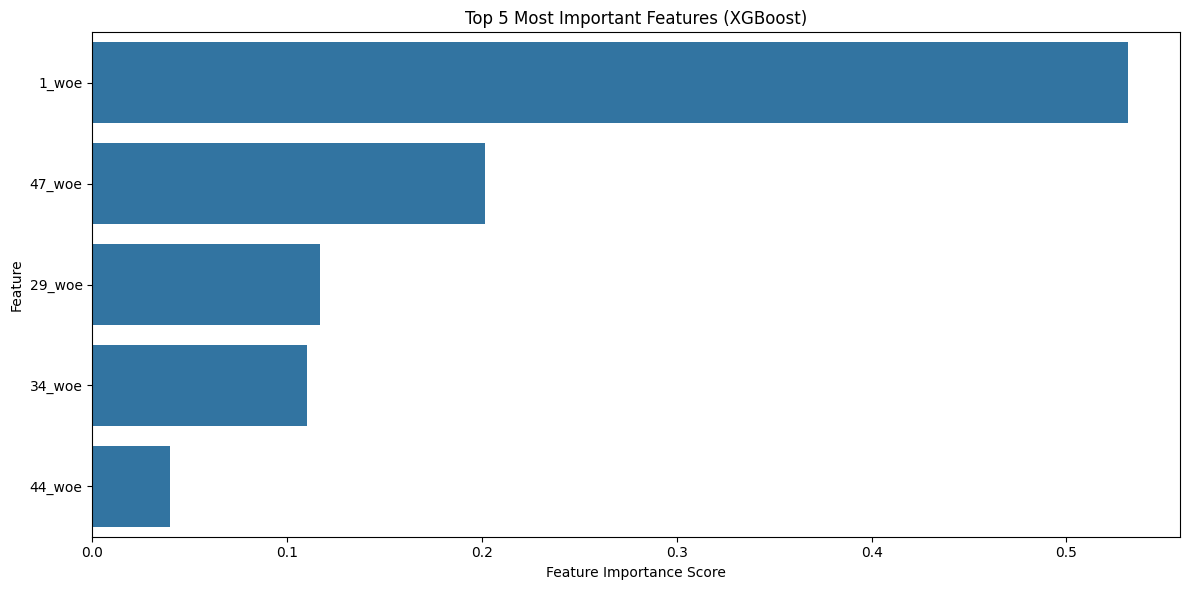

In [14]:
##Get top 10 most important features
feature_importance = pd.DataFrame({
        'feature': x_train_main.columns,
        'importance': results['xgboost']['model'].feature_importances_
})

# Sort by importance and get top N features
feature_importance = feature_importance.sort_values('importance', ascending=False)
top_features = feature_importance.head(5)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_features, x='importance', y='feature')
plt.title(f'Top 5 Most Important Features (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()

Checking with what we have in attributes description file, we can tell that model heavily depends on demographic information of <b>Customer Subtype</b>, following by <b>Contribution car policies</b>, <b>Social class D</b>, <b>No car</b> and <b>Contribution third party insurance</b> 

In [15]:
test_woe_encoded_df = pd.DataFrame(index=x_test.index)
    
##Process categorical column '1'
test_woe_encoded_df['1_woe'] = x_test['1'].map(woe_mappings['1'])
    
##Process numeric variables
for col in [col for col in x_test.columns if col != '1']:
    #Get bin edges from the IntervalIndex
    bins = pd.IntervalIndex(woe_mappings[col].index)
    binned_data = pd.cut(x_test[col].astype(float), bins=bins, include_lowest=True)
        
    #Create a WOE value mapping
    woe_dict = dict(zip(bins, woe_mappings[col].woe))
        
    #Map the bins to their corresponding WOE values
    test_woe_encoded_df[f'{col}_woe'] = binned_data.map(woe_dict)

test_woe_encoded_df.head(10)

,1_woe,2_woe,3_woe,4_woe,6_woe,7_woe,8_woe,9_woe,10_woe,11_woe,...,55_woe,56_woe,57_woe,58_woe,59_woe,60_woe,61_woe,62_woe,63_woe,64_woe
0,-0.054362,2.690881e-07,0.201443,-0.038108,-0.016806,-0.095586,-0.078442,0.001830,-0.173405,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.792767,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
1,0.567648,2.690881e-07,0.083231,-0.038108,-0.016806,0.083194,-0.078442,-0.137978,-0.173405,-0.090527,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.792767,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
2,-0.033335,2.690881e-07,0.083231,0.021621,-0.016806,-0.104994,0.189061,0.001830,-0.173405,-0.090527,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.792767,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
3,-0.343019,2.690881e-07,-0.169433,0.021621,0.223927,-0.206859,0.189061,-0.137978,-0.173405,-0.729504,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.227485,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
4,-0.745967,2.690881e-07,-0.169433,-0.002268,-0.016806,-0.202811,-0.078442,-0.441532,0.296632,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,-0.558315,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
5,-0.594318,2.690881e-07,-0.169433,-0.002268,-0.016806,-0.104994,0.189061,0.001830,-0.173405,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.792767,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
6,-0.492860,2.690881e-07,-0.169433,-0.002268,0.223927,0.083194,-0.078442,0.096014,0.296632,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,-0.558315,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
7,0.567648,2.690881e-07,0.083231,0.021621,-0.471272,-0.104994,0.189061,0.096014,0.296632,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,-0.558315,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
8,-0.463265,2.690881e-07,-0.169433,-0.002268,-0.016806,0.530449,0.189061,0.373467,0.296632,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,-0.558315,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07
9,-0.097059,2.690881e-07,0.201443,-0.038108,-0.016806,0.530449,-0.078442,0.096014,0.296632,0.051792,...,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,0.792767,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07,2.690881e-07


In [16]:
##Get top 800 predictions based on probability

##Predict on test set
pred_proba = model.predict_proba(test_woe_encoded_df)[:, 1]

##Create DataFrame with IDs and probabilities
predictions_df = pd.DataFrame({
    'ID': test_df['ID'],
    'probability': pred_proba
})
    
##Sort by probability and get top N
top_predictions = predictions_df.nlargest(800, 'probability')

##Print top 800 IDs
top_predictions['ID'].tolist()

[141,
 166,
 262,
 353,
 479,
 618,
 620,
 695,
 707,
 719,
 874,
 948,
 991,
 1207,
 1228,
 1243,
 1334,
 1468,
 1506,
 1558,
 1628,
 1755,
 1880,
 1883,
 1959,
 2113,
 2119,
 2123,
 2133,
 2165,
 2223,
 2241,
 2250,
 2253,
 2386,
 2389,
 2417,
 2504,
 2511,
 2516,
 2588,
 2635,
 2711,
 2799,
 2828,
 2844,
 2930,
 2962,
 3030,
 3093,
 3223,
 3348,
 3383,
 3483,
 3519,
 3619,
 3658,
 3748,
 3784,
 3801,
 3837,
 3843,
 3852,
 3863,
 3872,
 4000,
 2,
 8,
 12,
 22,
 30,
 46,
 52,
 94,
 103,
 114,
 130,
 136,
 138,
 145,
 151,
 155,
 171,
 182,
 188,
 199,
 210,
 213,
 215,
 230,
 239,
 244,
 253,
 255,
 265,
 276,
 283,
 286,
 294,
 296,
 314,
 331,
 332,
 333,
 341,
 345,
 365,
 370,
 374,
 380,
 383,
 403,
 406,
 444,
 446,
 455,
 462,
 466,
 470,
 471,
 500,
 502,
 505,
 519,
 542,
 561,
 564,
 570,
 572,
 573,
 584,
 585,
 596,
 598,
 632,
 638,
 639,
 641,
 687,
 688,
 697,
 702,
 717,
 729,
 736,
 737,
 747,
 753,
 754,
 760,
 762,
 764,
 766,
 772,
 775,
 785,
 787,
 813,
 818,
 81